### 决策树
- 简介
- 训练过程
    - 熵
    - 特征选择
    - 停止条件
- 低配版本
- 优缺点
- 扩展延伸
    - 回归树
    - 随机森林
    - XGboost
- sklearn使用

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree,DecisionTreeRegressor
from sklearn.inspection import DecisionBoundaryDisplay
from binarytree import tree,Node
import matplotlib as mpl
# print(mpl.matplotlib_fname())
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### 简介
决策树是一类监督学习模型,既可用于分类,也可用于回归.决策树是一种树状结构。对于二值特征，可以形成二叉树；对于具有多个离散取值的特征，也可以形成多叉树

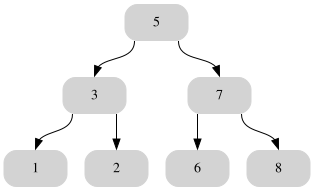

In [3]:
root=Node(5)
l1=Node(3)
r1=Node(7)
root.left=l1
root.right=r1

l21=Node(1)
r22=Node(2)
l1.left=l21
l1.right=r22

l23=Node(6)
r24=Node(8)
r1.left=l23
r1.right=r24
root.graphviz()


决策树与二叉树结构上相似,不同的地方在于节点的用途的不同.二叉树的节点是用来记录数据的,而决策树的除叶子的节点的所有节点则是用来做特征分类(条件判断),叶子节则是标签分类信息.决策树通俗来说就是训练一组if-else的判断集合来对数据进行分类.

比如,下面是根据三个特征[天气,温度,有风]来判断是否出门,是否出门为分类结果-常说的标签.下图粗略的画出了基于组数据的决策树结构,当想判断新数据属于那个分类,就依据这棵训练出来的树,从根节点开始于自身数据比较,一直分叉判断,直到走到最后的叶子节就知道该数据属于那个分类

| 天气 | 温度 | 有风 | 是否出门 |
|------|------|------|----------|
| 晴天 | 热   | 有   | 否       |
| 晴天 | 热   | 无   | 是       |
| 晴天 | 冷   | 有   | 否       |
| 晴天 | 冷   | 无   | 是       |
| 阴天 | 热   | 有   | 是       |
| 阴天 | 热   | 无   | 是       |
| 阴天 | 冷   | 有   | 否       |
| 阴天 | 冷   | 无   | 否       |


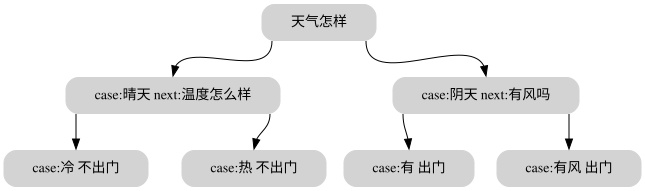

In [6]:
root=Node('天气怎样')
l1=Node("case:晴天 \n next:温度怎么样")
r1=Node("case:阴天 \n next:有风吗")
root.left=l1
root.right=r1

l21=Node("case:冷 \n 不出门 ")
r22=Node("case:热 \n 不出门")
l1.left=l21
l1.right=r22

l23=Node("case:有 \n 出门")
r24=Node("case:有风 \n 出门")
r1.left=l23
r1.right=r24
root.graphviz()

### 训练过程
了解决策树的结构后,接下来就是怎么来构造这棵树.它与其他监督学习算法不同,比如线性回归需要通过误差函数来求解最佳参数w.而它训练过程更为显式,利用贪心算法在构建节点挑选出最具有辨识度分类条件进行数据划分,直到触发停止条件为止.这套算法最核心的地方也在于此.
1. 怎么挑选特征作为节点判断条件
2. 何时结束节点的构造

#### 熵与条件熵
##### 信息量
对于一个事件X的信息量为I(x)=-logP(x).公式上来看当一个随机变量发生的概率很小,这件事携带的信息量越大.可以想象成现实中的黑天鹅事件,发生的概率很小很小,但其中的信息量巨头.如某一上市公司股价发生剧烈波动,该公司财务做假或其他原因.
##### 熵
熵是信息论中的一个基本概念,定义在随机变量之上,他是由随机变量所有可能结果的信息量的期望,熵衡量随机变量概率分布的不确定性.用$H(x)=- \sum_{i=1}^np_i\ln(p_i)$表示.$p_i$表示随机变量为i时的概率.样本越集中于某一个类别时，类别分布越确定，熵越小；当各类别样本越均匀时，熵越大.在决策树中，我们把一个节点中各类别的比例看作概率分布，因此可以用熵衡量这个节点的“纯度”。


##### 条件熵
在给定X的条件下Y的条件概率P(Y|X)的熵的期望,记为$H(Y|X)=\sum_{x=i}p(X)H(Y|X)$
$$
H(Y|X)=\sum_{x=i}p(X=x)H(Y|X=x)
$$ 
$$ =-\sum_{x=i}p(X=x)\sum_{y=j}p(Y=y|X=x)\ln(p(Y=y|X=x)) $$
根据联合概率公式$$\sum_{x=i}p(X)\sum_{y=j}p(Y|X)=\sum_{x=i}\sum_{j=i}P(X \cap Y)$$
所以$$H(Y|X)=-\sum_{x=i}\sum_{j=i}P(X=x;Y=y)\ln(\frac{P(X=x;Y=y)}{P(X=x)})$$

> 条件熵的含义根据随机变量X的取值将整个数据集划分成多个子集,计算每子集内的熵



观察下面二分类的熵图像,当p越集中于某一区域,熵越低.如图当p趋于0或1时熵越小,确定性就越高.反之模糊不清的状态下,熵越高

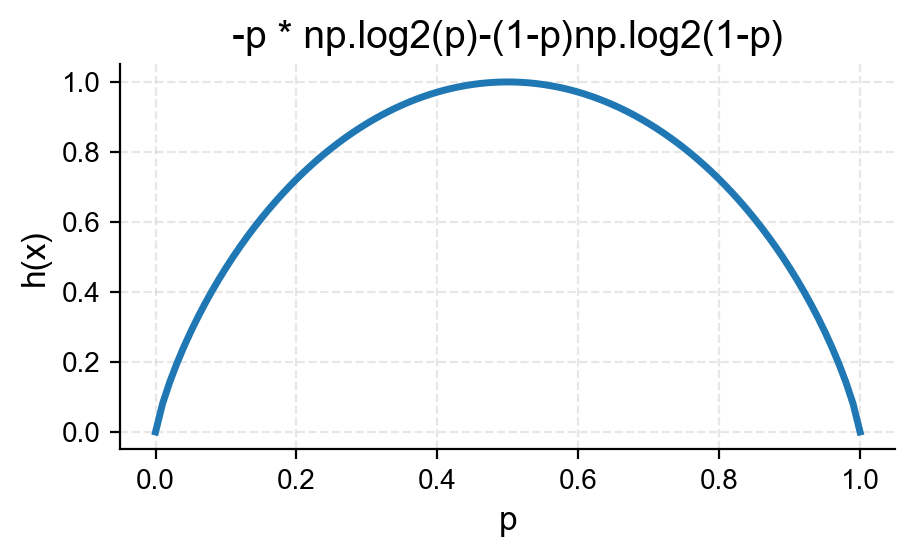

In [38]:
p=np.linspace(0,1,101)
mask=np.logical_and(p>0,p<1)
h=np.zeros_like(p)
h[mask]=-p[mask]*np.log2(p[mask])-(1-p[mask])*np.log2((1-p[mask]))
# h = np.where(p == 0, 0, -p * np.log2(p))  # where先计算全部在进行替换
plt.plot(p,h)
plt.title('-p * np.log2(p)-(1-p)np.log2(1-p)')
ax=plt.gca()
ax.set_xlabel('p')
ax.set_ylabel('h(x)')
plt.show()


#### 特征选择
有了前面对熵和条件熵的了解,就可以了解下面的公式.
$$G=H(D)-\sum_{i=0} \frac{D_i}{D} H(D_i)$$
H(D)表示未分类此时系统的熵(衡量系统的不确定性),后面那的sum式子表示分类后各个新节点的熵,为了使样本数量更多的子节点对总体条件熵的贡献更大,所以用$\frac{D_i}{D}$作为子节点熵的加权平均,D样本总数,$D_i$分类后样本i状态的数量.
```
比如
节点D：100个样本
子节点A：99个
子节点B：1个
99/100​H(A)+1/100​H(B)
```

因此G就可以看成,G=划分前不确定性-划分后的不确定性,G越大就表示分类效果好,因为系统熵的确定的,分类会式系统熵发生变化,如果分类后熵变小说明此时系统确定性高,分类效果好;如果分类后熵变大说明此时系统不确定性高,分类效果不好.
> G这个表达式叫信息增益,G=H(D)-H(D|X),G(Y,X)=I(X;Y)信息熵实际就是随机变量X,Y之间的互信息;所以完整I(X;Y)=H(Y)-H(Y|X),这样就看到决策树其实是寻找一个特征X,能够最大程度降低Y的不确定性

前面说了用到了条件熵,这体现在哪里.现在就拆开来讲解,把公式换成下面这个样(权重没计算).假设当前节点中的特征 X 为“天气”，它有两个取值：晴、阴；标签 Y 为“是否出门”。

$$G=H(D)-\sum_{i=0}^1p(X_i)H(Y|X)$$
- X:天气
- Y:出门
- $X_i$:天气某一具体取值,阴或晴
- H(Y|X=xi):在天气确定为xi的情况下,是否出门的不确定性
因此当X=天气
H(Y|X)=P(晴)H(Y|晴)+P(阴)H(Y|阴),按照天气这个特征划分数据集后,分别计算每个子节点的熵,再按照子节点的样本比例进行加权平均
所以信息增益:信息增益=划分前不确定-划分后的不确定


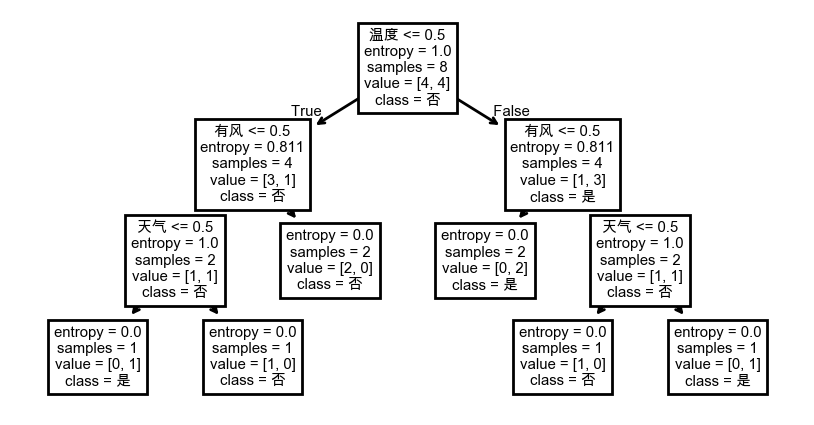

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'STHeiti', 'Arial Unicode MS']
data = {
    '天气': ['晴天', '晴天', '晴天', '晴天', '阴天', '阴天', '阴天', '阴天'],
    '温度': ['热', '热', '冷', '冷', '热', '热', '冷', '冷'],
    '有风': ['有', '无', '有', '无', '有', '无', '有', '无'],
    '外出': ['否', '是', '否', '是', '是', '是', '否', '否']
}
df=pd.DataFrame(data=data)
# sparse_output 稀疏矩阵多用array不节约内存,drop删除重复的列if_binary合并删除 frist删除第一列
encoder=OneHotEncoder(sparse_output=False,drop='if_binary')

data=encoder.fit_transform(df)

model=DecisionTreeClassifier(max_depth=3,criterion='entropy')
model.fit(data[:,:3],data[:,[-1]])
tree=plot_tree(model,feature_names=df.columns,class_names=['否','是'])
# 抑制（隐藏）函数的返回值输出
tree;

以上面那个例子为例,构建决策树头节点
出门=4;不出门4;总量=8
1. 计算现在系统的熵
$H(D)=-(\frac{1}{2}\ln{\frac{1}{2}}+\frac{1}{2} \ln{\frac{1}{2}})=1$
   
2. 分别计算用温度,天气,有风这三个条件进行分类后的熵.这里用温度举例也就是上面那副图

    热=4;冷=4,总量=8;所以这两个条件熵前面的系统$\frac{1}{2}$

    在热分类下出门的数据=3;在热分类下不出门的数据=1;在冷分类下出门的数据=1;在冷分类下不出门的数据=3;

    - D(是否出门|热)=$-(\frac{3}{4}ln{\frac{3}{4}}+\frac{1}{4}ln{\frac{1}{4}})=0.811$
    - D(是否出门|冷)=$-(\frac{1}{4}ln{\frac{1}{4}}+\frac{3}{4}ln{\frac{3}{4}})=0.811$
3. 计算信息增益,与其他特征比较找出最大增益来作为当前节点条件
$$H(D)-\frac{1}{2}((是否出门|热)+ D(是否出门|冷))=0.189$$
$$G(Y,温度)=H(Y)-H(Y|温度)$$

4. 递归的从上面分类中再次重复1,2,3
> 我们的数据类型是离散的只有0和1,而它这里用Xi连续数据,通过寻找阈值t,Xi<t和Xi>=t形成两个子节点进行划分

In [ ]:

def entropy(y):
    l=len(y)
    ent=0
    if l==0:
        return ent
    p1=len(y[y==1])/l
    p0=len(y[y==0])/l
 
    ent=-p0*np.log2(p0)-p1*np.log2(p1)
    return ent

def spilt_node(X_train,indices,n_feature):
    left=[]
    right=[]
    for _ in indices:
        val=X_train[_,n_feature]
        if val==1:
            left.append(_)
        else:
            right.append(_)
    return left,right

def choose_best_feature(X_train,y_train,indices):
    features=X_train.shape[1]
    best_score=0
    best_feature=-1
    root_entropy=entropy(y_train[indices])
    total=len(indices)
    for _ in range(features):
        left,right=spilt_node(X_train,indices,_)
        l=len(left)
        r=len(right)
        wl,wr=l/total,r/total
        score=root_entropy-wl*entropy(y_train[left])-wr*entropy(y_train[right])
        if best_score< score:
            best_score=score
            best_feature=_
    return best_feature
indices=[i for i in range(8)]   
idx=choose_best_feature(data[:,:3],data[:,-1],indices)
df.columns[idx]

In [ ]:
# get_dummies替代方法
ata = {
    '天气': ['晴天', '晴天', '晴天', '晴天', '阴天', '阴天', '阴天', '阴天'],
    '温度': ['热', '热', '冷', '冷', '热', '热', '冷', '冷'],
    '有风': ['有', '无', '有', '无', '有', '无', '有', '无'],
    '是否出门': ['否', '是', '否', '是', '是', '是', '否', '否']
}
df=pd.DataFrame(data=data)
pd.get_dummies(df,drop_first=True,dtype='int')



#### 停止条件
停止条件避免生成的决策树出现过度拟合,所以在有些情况下需要提前停止创建节点.常见的参数
1. 分类成功,纯度为100%表示所有样本属同一类自然停止
2. 树深度(`max_depth`),宏观控制防止树极深,适用于特征多的场景
3. 节点最小样本数(`min_samples_split`),节点样本低于多少时停止,适用于有异常值噪声比较高的数据集
4. 信息增益阈值(`min_impurity_decreas`),收益成本控制每次切分带来收益很小,适用于连续变量很多,容易产生细微碎片

In [3]:
X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])

[Text(0.5, 0.8333333333333334, 'x[2] <= 0.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.5, 'x[1] <= 0.5\nentropy = 0.722\nsamples = 5\nvalue = [4, 1]'),
 Text(0.125, 0.16666666666666666, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.5, 'x[0] <= 0.5\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]')]

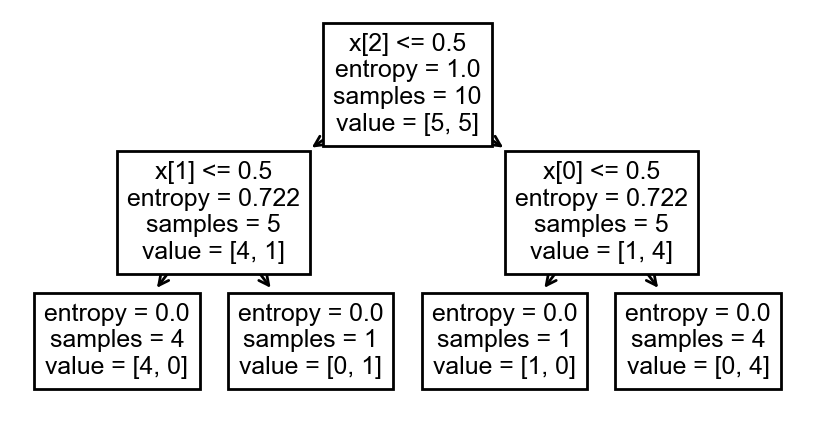

In [ ]:
decision=DecisionTreeClassifier(max_depth=2,criterion='entropy',)
model=decision.fit(X_train,y_train)
plot_tree(model);

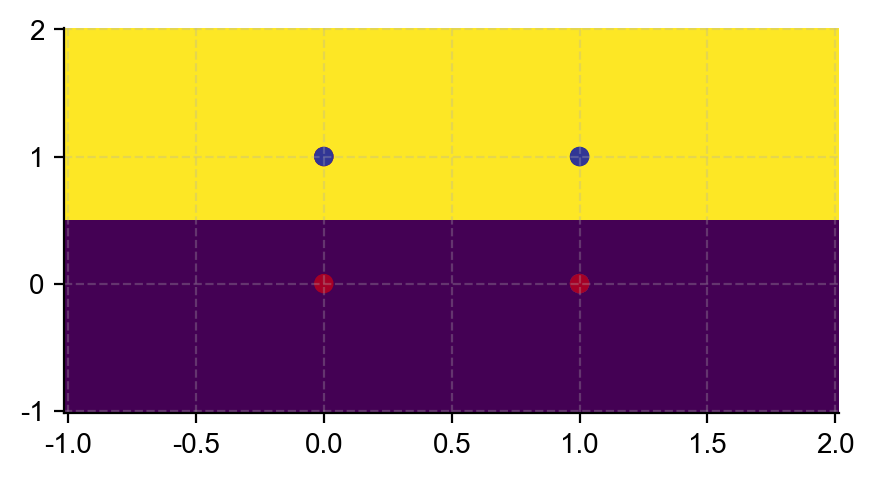

In [5]:
X_2_f=X_train[:,:2]
tree2=DecisionTreeClassifier(max_depth=1)
tree2.fit(X_2_f,y_train)
fig,ax=plt.subplots()
DecisionBoundaryDisplay.from_estimator(tree2,X=X_2_f,response_method='predict',ax=ax,plot_method='pcolormesh')

ax.scatter(X_2_f[:,0],X_2_f[:,1],c=y_train,cmap='RdYlBu')


[Text(0.5, 0.8333333333333334, 'x[0] <= 0.197\nsquared_error = 0.098\nsamples = 200\nvalue = 0.354'),
 Text(0.25, 0.5, 'x[0] <= 0.092\nsquared_error = 0.038\nsamples = 44\nvalue = 0.689'),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.018\nsamples = 20\nvalue = 0.854'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.013\nsamples = 24\nvalue = 0.552'),
 Text(0.75, 0.5, 'x[0] <= 0.772\nsquared_error = 0.074\nsamples = 156\nvalue = 0.259'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.015\nsamples = 110\nvalue = 0.111'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.036\nsamples = 46\nvalue = 0.615')]

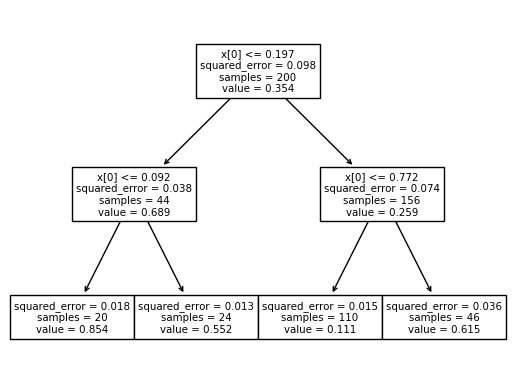

In [ ]:
# Quadratic training set + noise
np.random.seed(42)
m = 200
X = np.random.rand(m, 1)
y = 4 * (X - 0.5) ** 2

y = y + np.random.randn(m, 1) / 10


tree_regressor=DecisionTreeRegressor(max_depth=2)
tree_regressor.fit(X,y)
plot_tree(tree_regressor);

(array([[0.        ],
        [0.00200401],
        [0.00400802],
        [0.00601202]]),
 array([0.85389715, 0.85389715, 0.85389715, 0.85389715]))

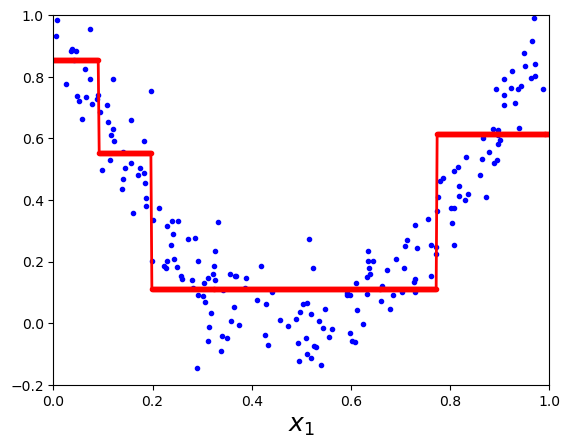

In [ ]:
axes=[0, 1, -0.2, 1]
x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
y_pred = tree_regressor.predict(x1)
plt.axis(axes)
plt.xlabel("$x_1$", fontsize=18)

plt.plot(X, y, "b.")
plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

分类树的叶节点输出的是类别（更准确地说通常是训练样本中类别概率/多数类）；回归树的叶节点输出的是该叶节点训练样本目标值的平均值。

In [1]:
import matplotlib
print(matplotlib.matplotlib_fname())

/opt/anaconda3/envs/homl3/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc
